In [1]:
import joblib 
import os 
import sys 
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, parent_dir)


In [63]:
generated_data = joblib.load(parent_dir + f'/results/GAN_only/Oct1_all_seed_generated_data.pkl')
simulated_v_pf_data = joblib.load(parent_dir + f'/results/GAN_only/Oct1_all_seed_simulated_v_pf_data.pkl')
all_losses_seeds = joblib.load(parent_dir + f'/results/GAN_only/Oct1_all_seed_losses_data.pkl')

seeds = np.arange(len(generated_data.keys()))

generated_v_df = pd.DataFrame(columns=seeds)
simulated_v_pf_data_df = pd.DataFrame(columns=seeds)
all_val_g_losses_df = pd.DataFrame(columns=seeds)
all_val_d_losses_df = pd.DataFrame(columns=seeds)
all_val_d_accuracies_df = pd.DataFrame(columns=seeds)

num_buses = 42

for seed in seeds: 
    all_val_g_losses_df[seed] = all_losses_seeds[seed]['val_g_losses']
    all_val_d_losses_df[seed] = all_losses_seeds[seed]['val_d_losses']
    all_val_d_accuracies_df[seed] = all_losses_seeds[seed]['val_d_accuracies']
    try: 
        generated_v_df[seed] = generated_data[seed]['gen_v'][:num_buses]
        simulated_v_pf_data_df[seed] = simulated_v_pf_data[seed]
    except Exception as e: 
        print(e)
# generated_v_df.dropna(axis='columns', inplace=True)
# simulated_v_pf_data_df.dropna(axis='columns', inplace=True)


In [64]:
any(generated_v_df.count().isna())

False

In [65]:
val_d_losses_mean = all_val_d_losses_df.mean(axis=1)
val_d_losses_std = all_val_d_losses_df.std(axis=1)

val_g_losses_mean = all_val_g_losses_df.mean(axis=1)
val_g_losses_std = all_val_g_losses_df.std(axis=1)

val_d_accuracies_mean = all_val_d_accuracies_df.mean(axis=1)
val_d_accuracies_std = all_val_d_accuracies_df.std(axis=1)

x = range(len(val_d_losses_mean))

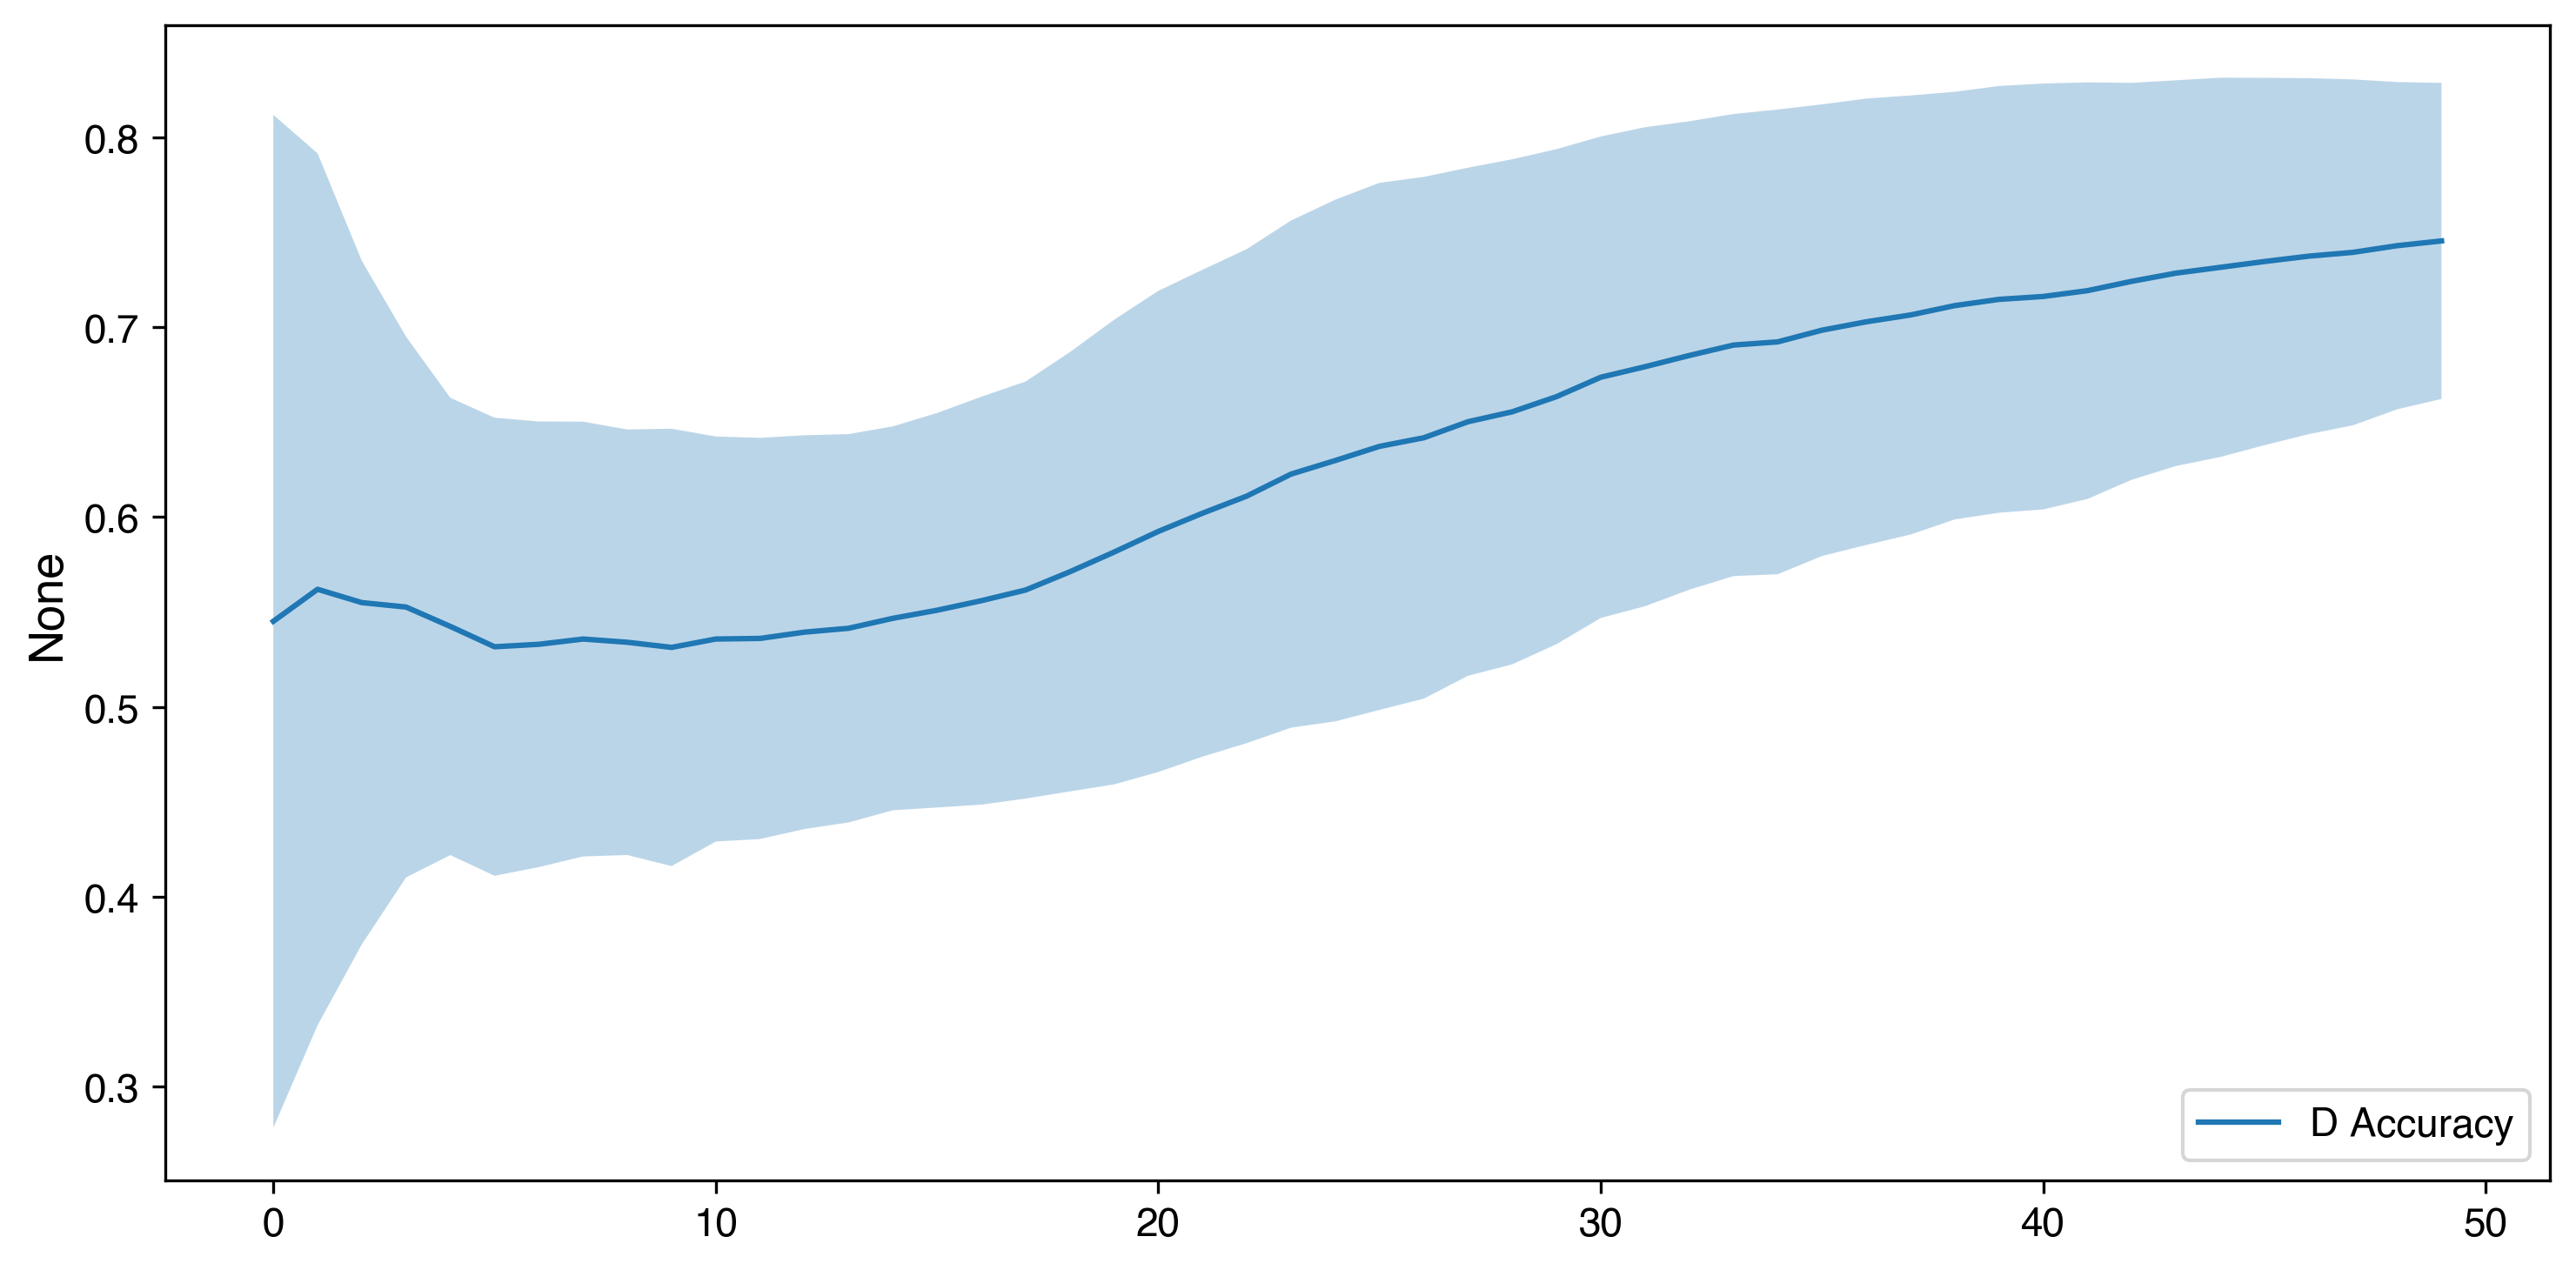

In [66]:
fig, ax = plt.subplots(figsize=(10,5))
sns.lineplot(x=x, y=val_d_accuracies_mean, label='D Accuracy')
ax.fill_between(x, val_d_accuracies_mean - val_d_accuracies_std, val_d_accuracies_mean + val_d_accuracies_std, alpha=0.3)
plt.tight_layout()


### Figure: Discriminator accuracy vs. epochs 

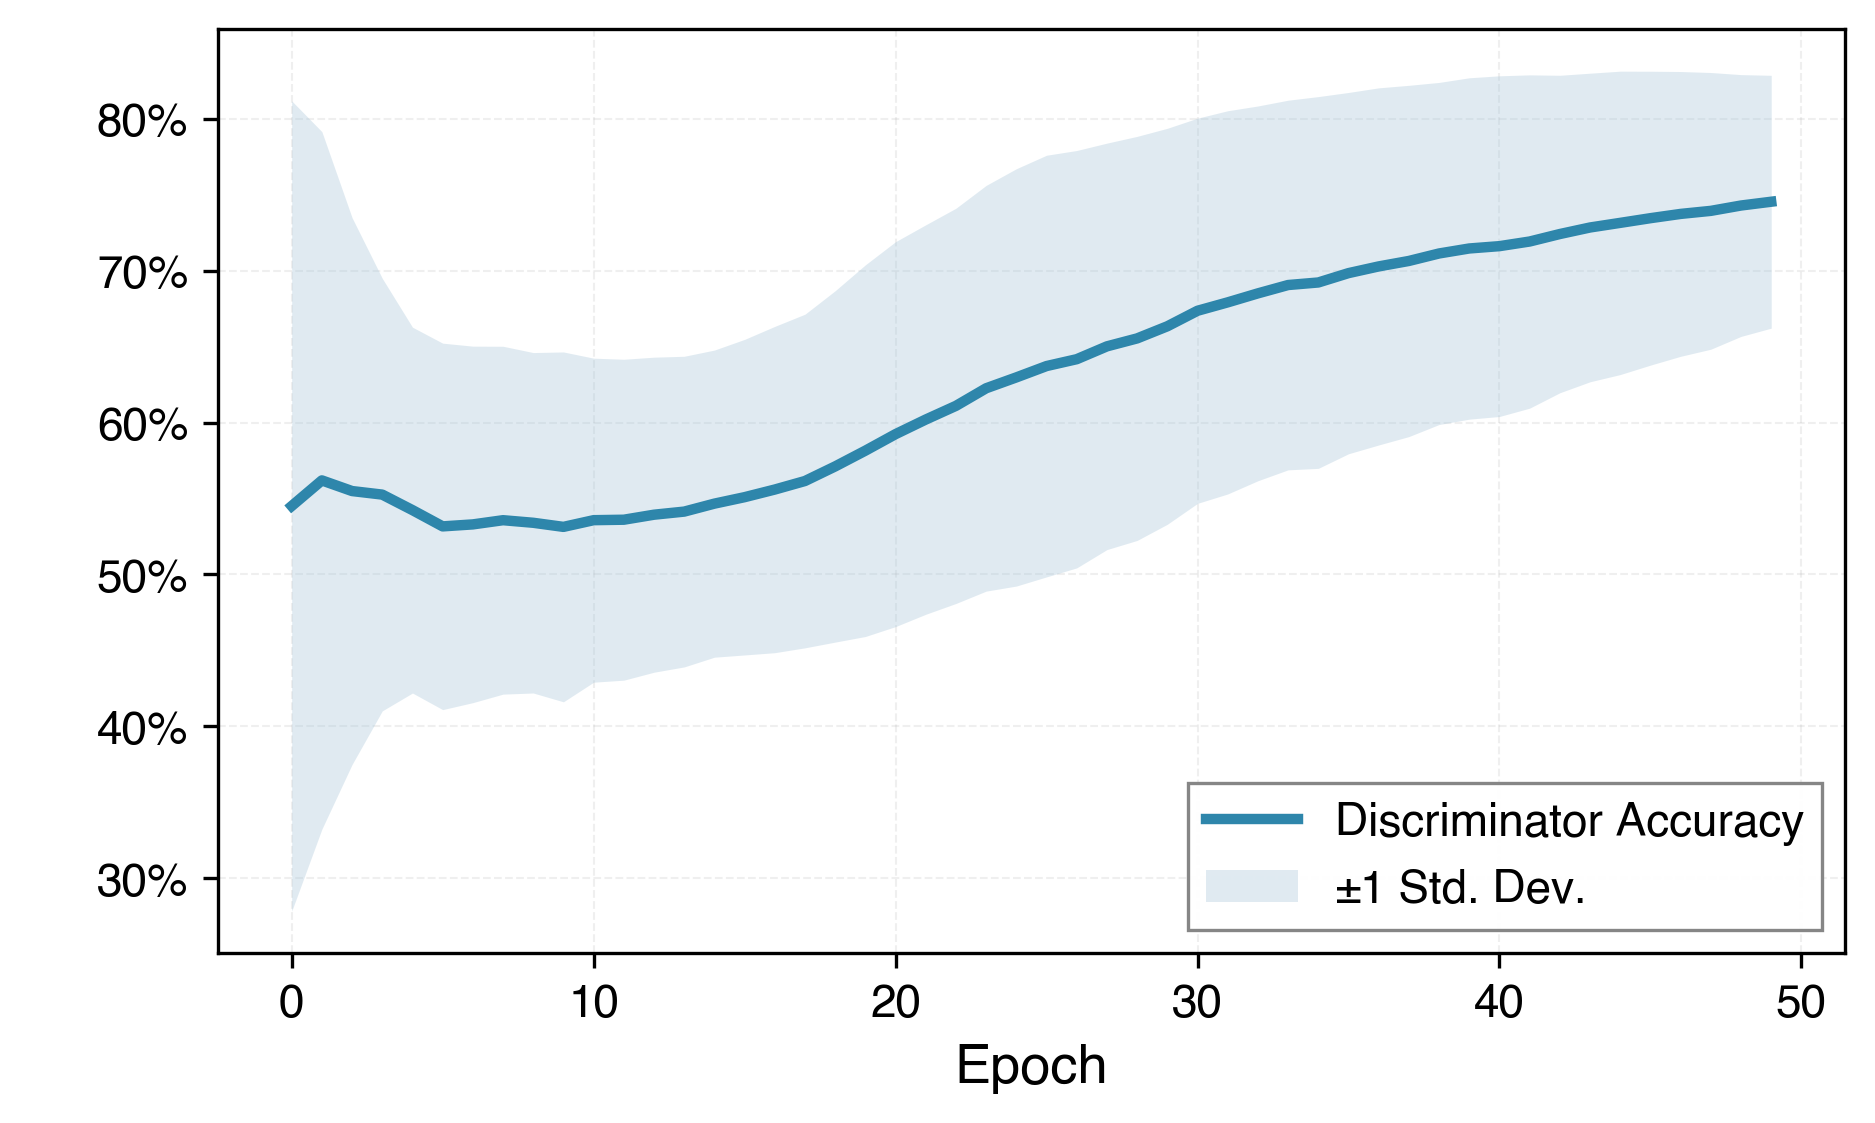

In [67]:
# Set publication-quality style with modern academic fonts
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stixsans'  # Modern math font
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'semibold'

# Create figure with better proportions
fig, ax = plt.subplots(figsize=(7, 4))

# Use a sophisticated color palette
color = '#2E86AB'  # Professional blue
fill_color = '#A7C5D9'  # Lighter blue for confidence interval

# Plot with refined styling
line = ax.plot(x, val_d_accuracies_mean, 
               color=color, 
               linewidth=2.5, 
               label='Discriminator Accuracy',
               zorder=3)

# Confidence interval with subtle transparency
ax.fill_between(x, 
                val_d_accuracies_mean - val_d_accuracies_std, 
                val_d_accuracies_mean + val_d_accuracies_std, 
                color=fill_color,
                alpha=0.35,
                linewidth=0,
                label='±1 Std. Dev.',
                zorder=2)

# Styling improvements
ax.set_xlabel('Epoch', fontweight='normal')
ax.set_ylabel('  ', fontweight='normal')
# ax.set_title('Discriminator Performance During Training', 
#              fontweight='normal', pad=15)

# Add grid for readability (subtle)
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=1)
ax.set_axisbelow(True)

# Set y-axis to percentage if needed (0-1 range)
if val_d_accuracies_mean.max() <= 1.0:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Clean up spines
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible()
# ax.spines['left'].set_linewidth(0.8)
# ax.spines['bottom'].set_linewidth(0.8)

# Legend with refined styling
legend = ax.legend(frameon=True, 
                   loc='best',
                   framealpha=0.95,
                   edgecolor='gray',
                   fancybox=False,
                   shadow=False)
legend.get_frame().set_linewidth(0.8)

# Tight layout with padding
# plt.tight_layout(pad=0.0)

# Save as high-quality PDF and PNG
plt.savefig('discriminator_accuracy.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('discriminator_accuracy.png', dpi=300, bbox_inches='tight')

plt.show()

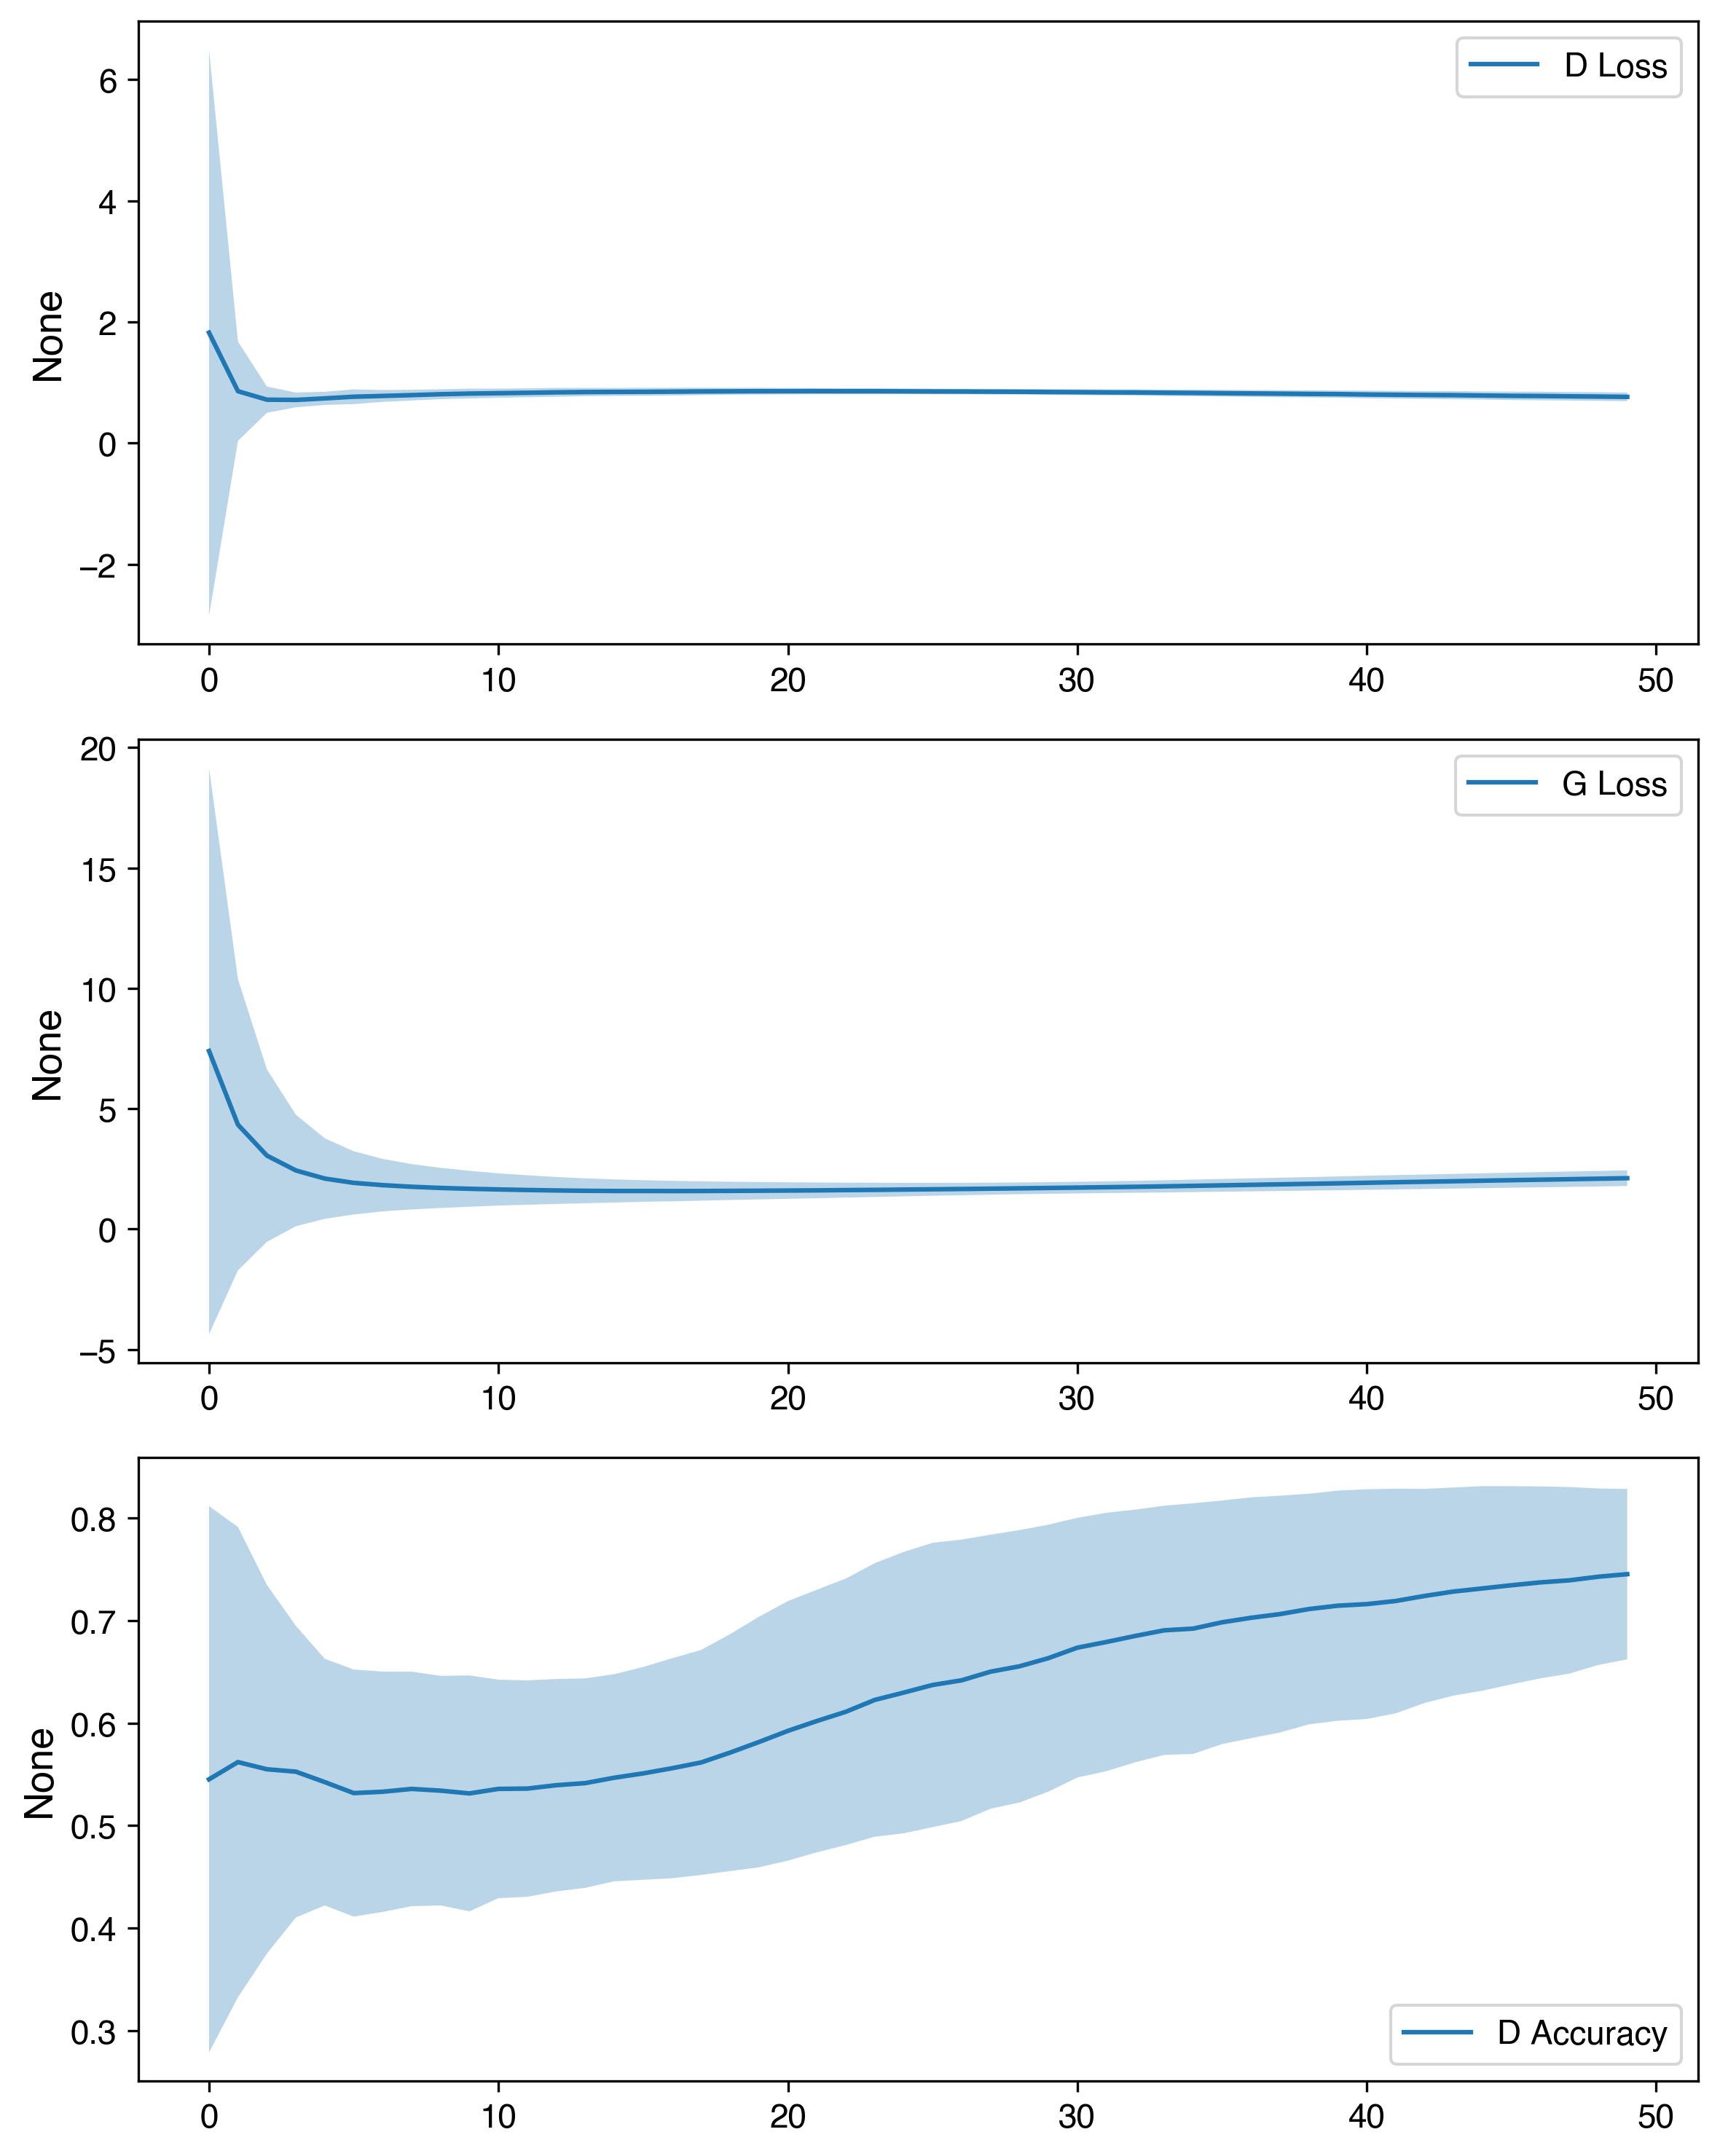

In [8]:
val_d_losses_mean = all_val_d_losses_df.mean(axis=1)
val_d_losses_std = all_val_d_losses_df.std(axis=1)

val_g_losses_mean = all_val_g_losses_df.mean(axis=1)
val_g_losses_std = all_val_g_losses_df.std(axis=1)

val_d_accuracies_mean = all_val_d_accuracies_df.mean(axis=1)
val_d_accuracies_std = all_val_d_accuracies_df.std(axis=1)

fig, ax = plt.subplots(3,1, figsize=(8,10))
x = range(len(val_d_losses_mean))

sns.lineplot(x=x, y=val_d_losses_mean, ax=ax[0], label='D Loss')
ax[0].fill_between(x, val_d_losses_mean - val_d_losses_std, val_d_losses_mean + val_d_losses_std, alpha=0.3)

sns.lineplot(x=x, y=val_g_losses_mean, ax=ax[1], label='G Loss')
ax[1].fill_between(x, val_g_losses_mean - val_g_losses_std, val_g_losses_mean + val_g_losses_std, alpha=0.3)

sns.lineplot(x=x, y=val_d_accuracies_mean, ax=ax[2], label='D Accuracy')
ax[2].fill_between(x, val_d_accuracies_mean - val_d_accuracies_std, val_d_accuracies_mean + val_d_accuracies_std, alpha=0.3)

plt.tight_layout()
plt.show()

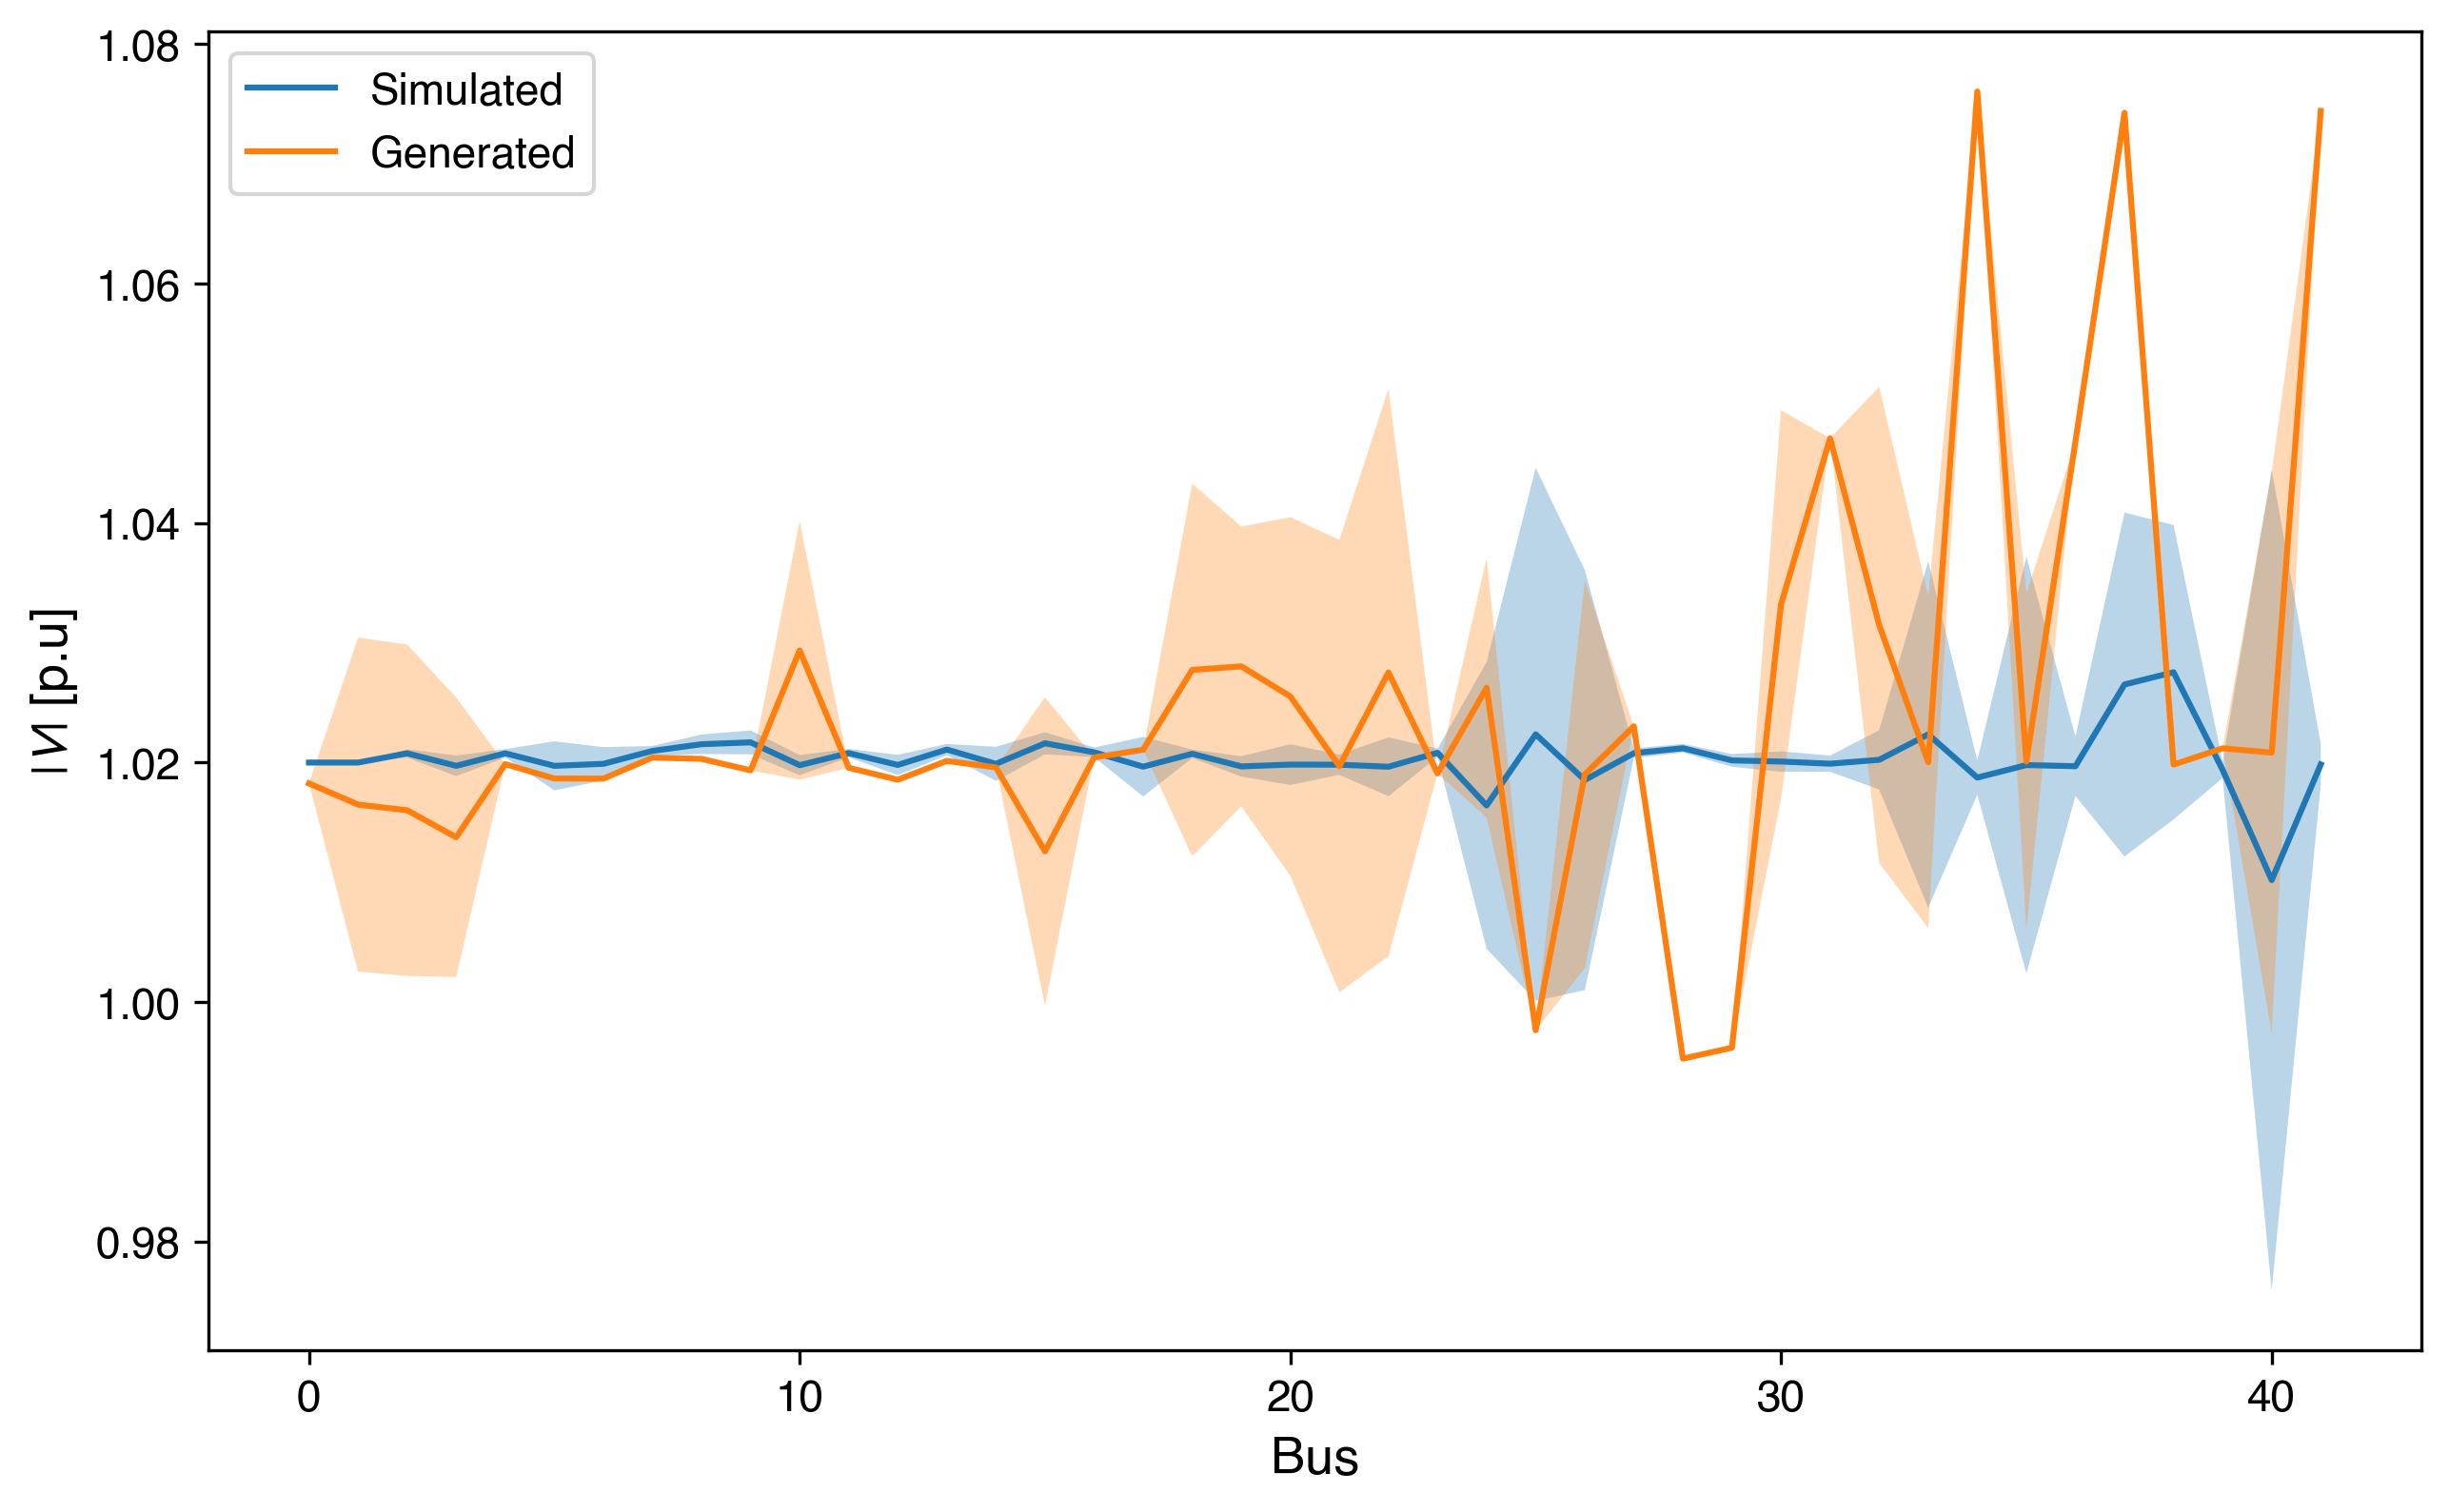

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Calculate mean and standard deviation for both dataframes
simulated_mean = simulated_v_pf_data_df.mean(axis=1)
simulated_std = simulated_v_pf_data_df.std(axis=1)
generated_mean = generated_v_df.mean(axis=1)
generated_std = generated_v_df.std(axis=1)

# Create the plot
plt.figure(figsize=(10, 6))
x = range(len(simulated_mean))
sns.lineplot(x=x, y=simulated_mean, label='Simulated')
plt.fill_between(x, simulated_mean - simulated_std, simulated_mean + simulated_std, alpha=0.3)
sns.lineplot(x=x, y=generated_mean, label='Generated')
plt.fill_between(x, generated_mean - generated_std, generated_mean + generated_std, alpha=0.3)
plt.xlabel('Bus')
plt.ylabel('|V| [p.u]')
plt.legend()
plt.show()

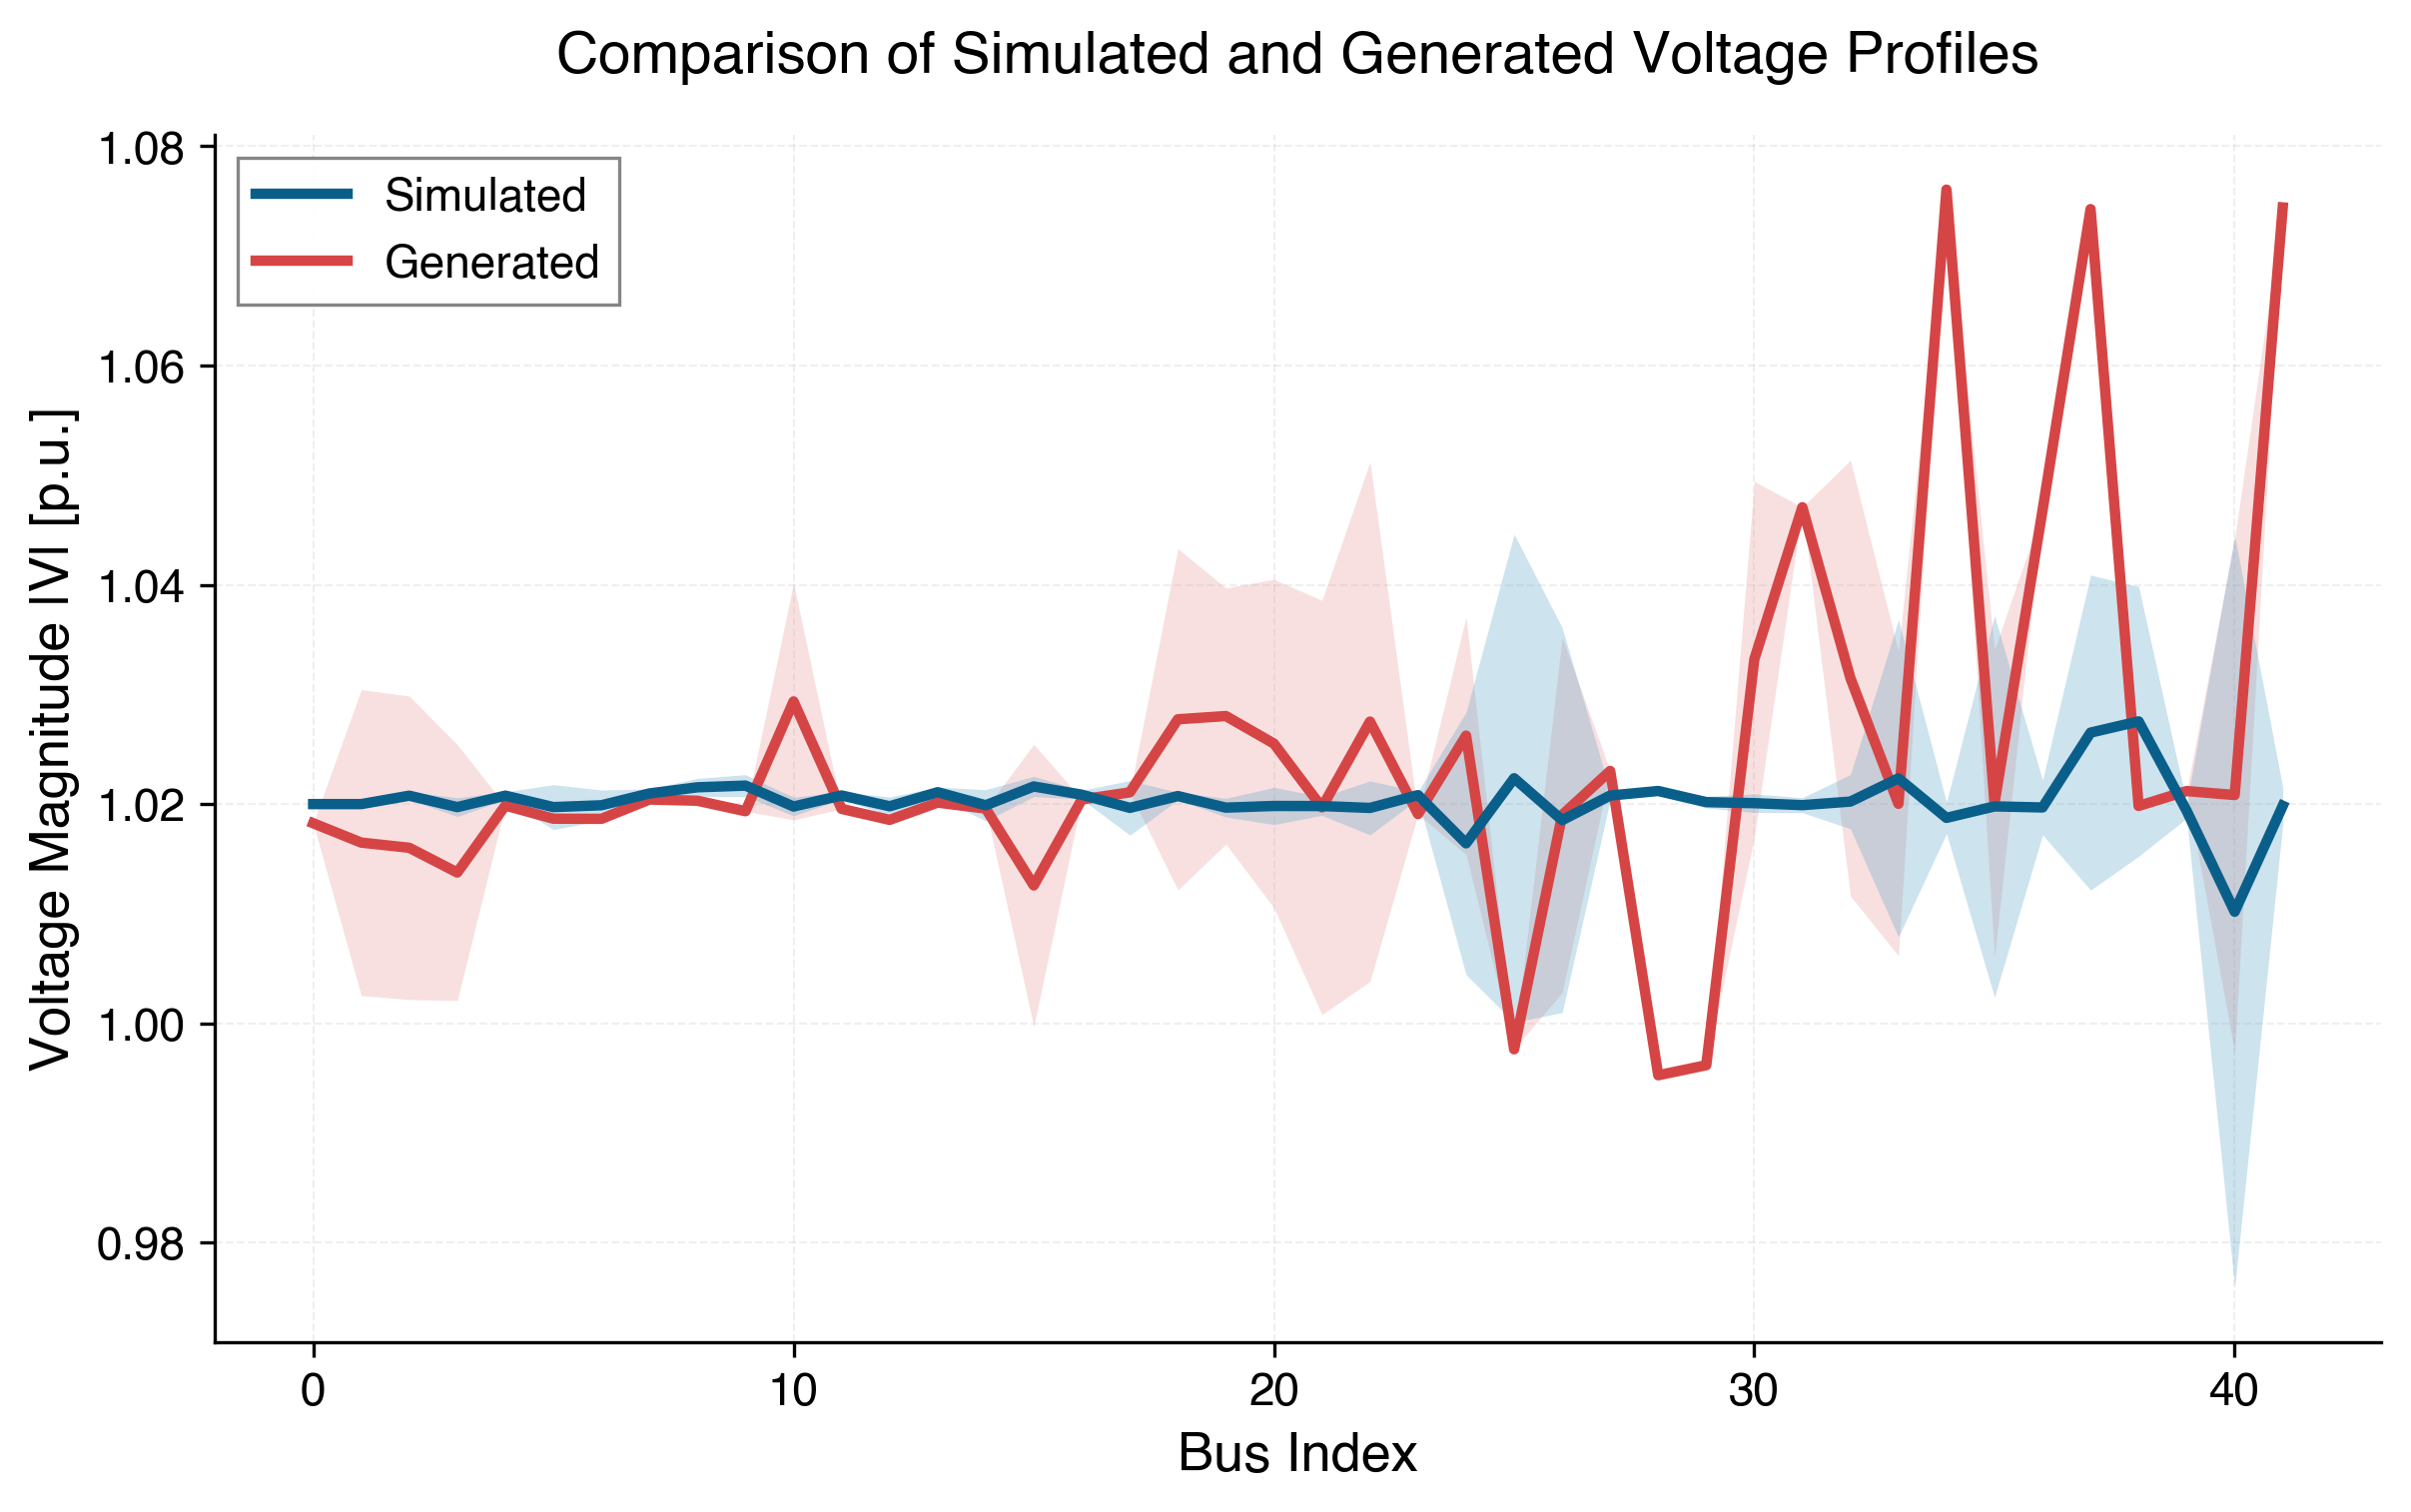

In [58]:
# Set publication-quality style with modern fonts
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stixsans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'semibold'

# Create figure with better proportions
fig, ax = plt.subplots(figsize=(8, 5))

# Professional color palette
color_simulated = '#0A5F8A'  # Deep blue
color_generated = '#D64545'  # Warm red
fill_sim = '#5BA3C7'  # Light blue
fill_gen = '#E89B9B'  # Light red

x = range(len(simulated_mean))

# Plot simulated data
ax.plot(x, simulated_mean, 
        color=color_simulated, 
        linewidth=2.5, 
        label='Simulated',
        zorder=4)
ax.fill_between(x, 
                simulated_mean - simulated_std, 
                simulated_mean + simulated_std, 
                color=fill_sim,
                alpha=0.3,
                linewidth=0,
                zorder=2)

# Plot generated data
ax.plot(x, generated_mean, 
        color=color_generated, 
        linewidth=2.5, 
        label='Generated',
        zorder=3)
ax.fill_between(x, 
                generated_mean - generated_std, 
                generated_mean + generated_std, 
                color=fill_gen,
                alpha=0.3,
                linewidth=0,
                zorder=1)

# Labels with proper formatting
ax.set_xlabel('Bus Index', fontweight='normal')
ax.set_ylabel('Voltage Magnitude |V| [p.u.]', fontweight='normal')
ax.set_title('Comparison of Simulated and Generated Voltage Profiles', 
             fontweight='semibold', pad=15)

# Add subtle grid
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

# # Optional: Add reference line at 1.0 p.u. (nominal voltage)
# ax.axhline(y=1.0, color='gray', linestyle=':', linewidth=1.2, 
#            alpha=0.6, zorder=1, label='Nominal (1.0 p.u.)')

# Legend with refined styling
legend = ax.legend(frameon=True, 
                   loc='best',
                   framealpha=0.95,
                   edgecolor='gray',
                   fancybox=False,
                   shadow=False)
legend.get_frame().set_linewidth(0.8)

# Tight layout
plt.tight_layout(pad=0.5)

# Save options
plt.savefig('FIG_voltage_comparison.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('voltage_comparison.png', dpi=300, bbox_inches='tight')

plt.show()

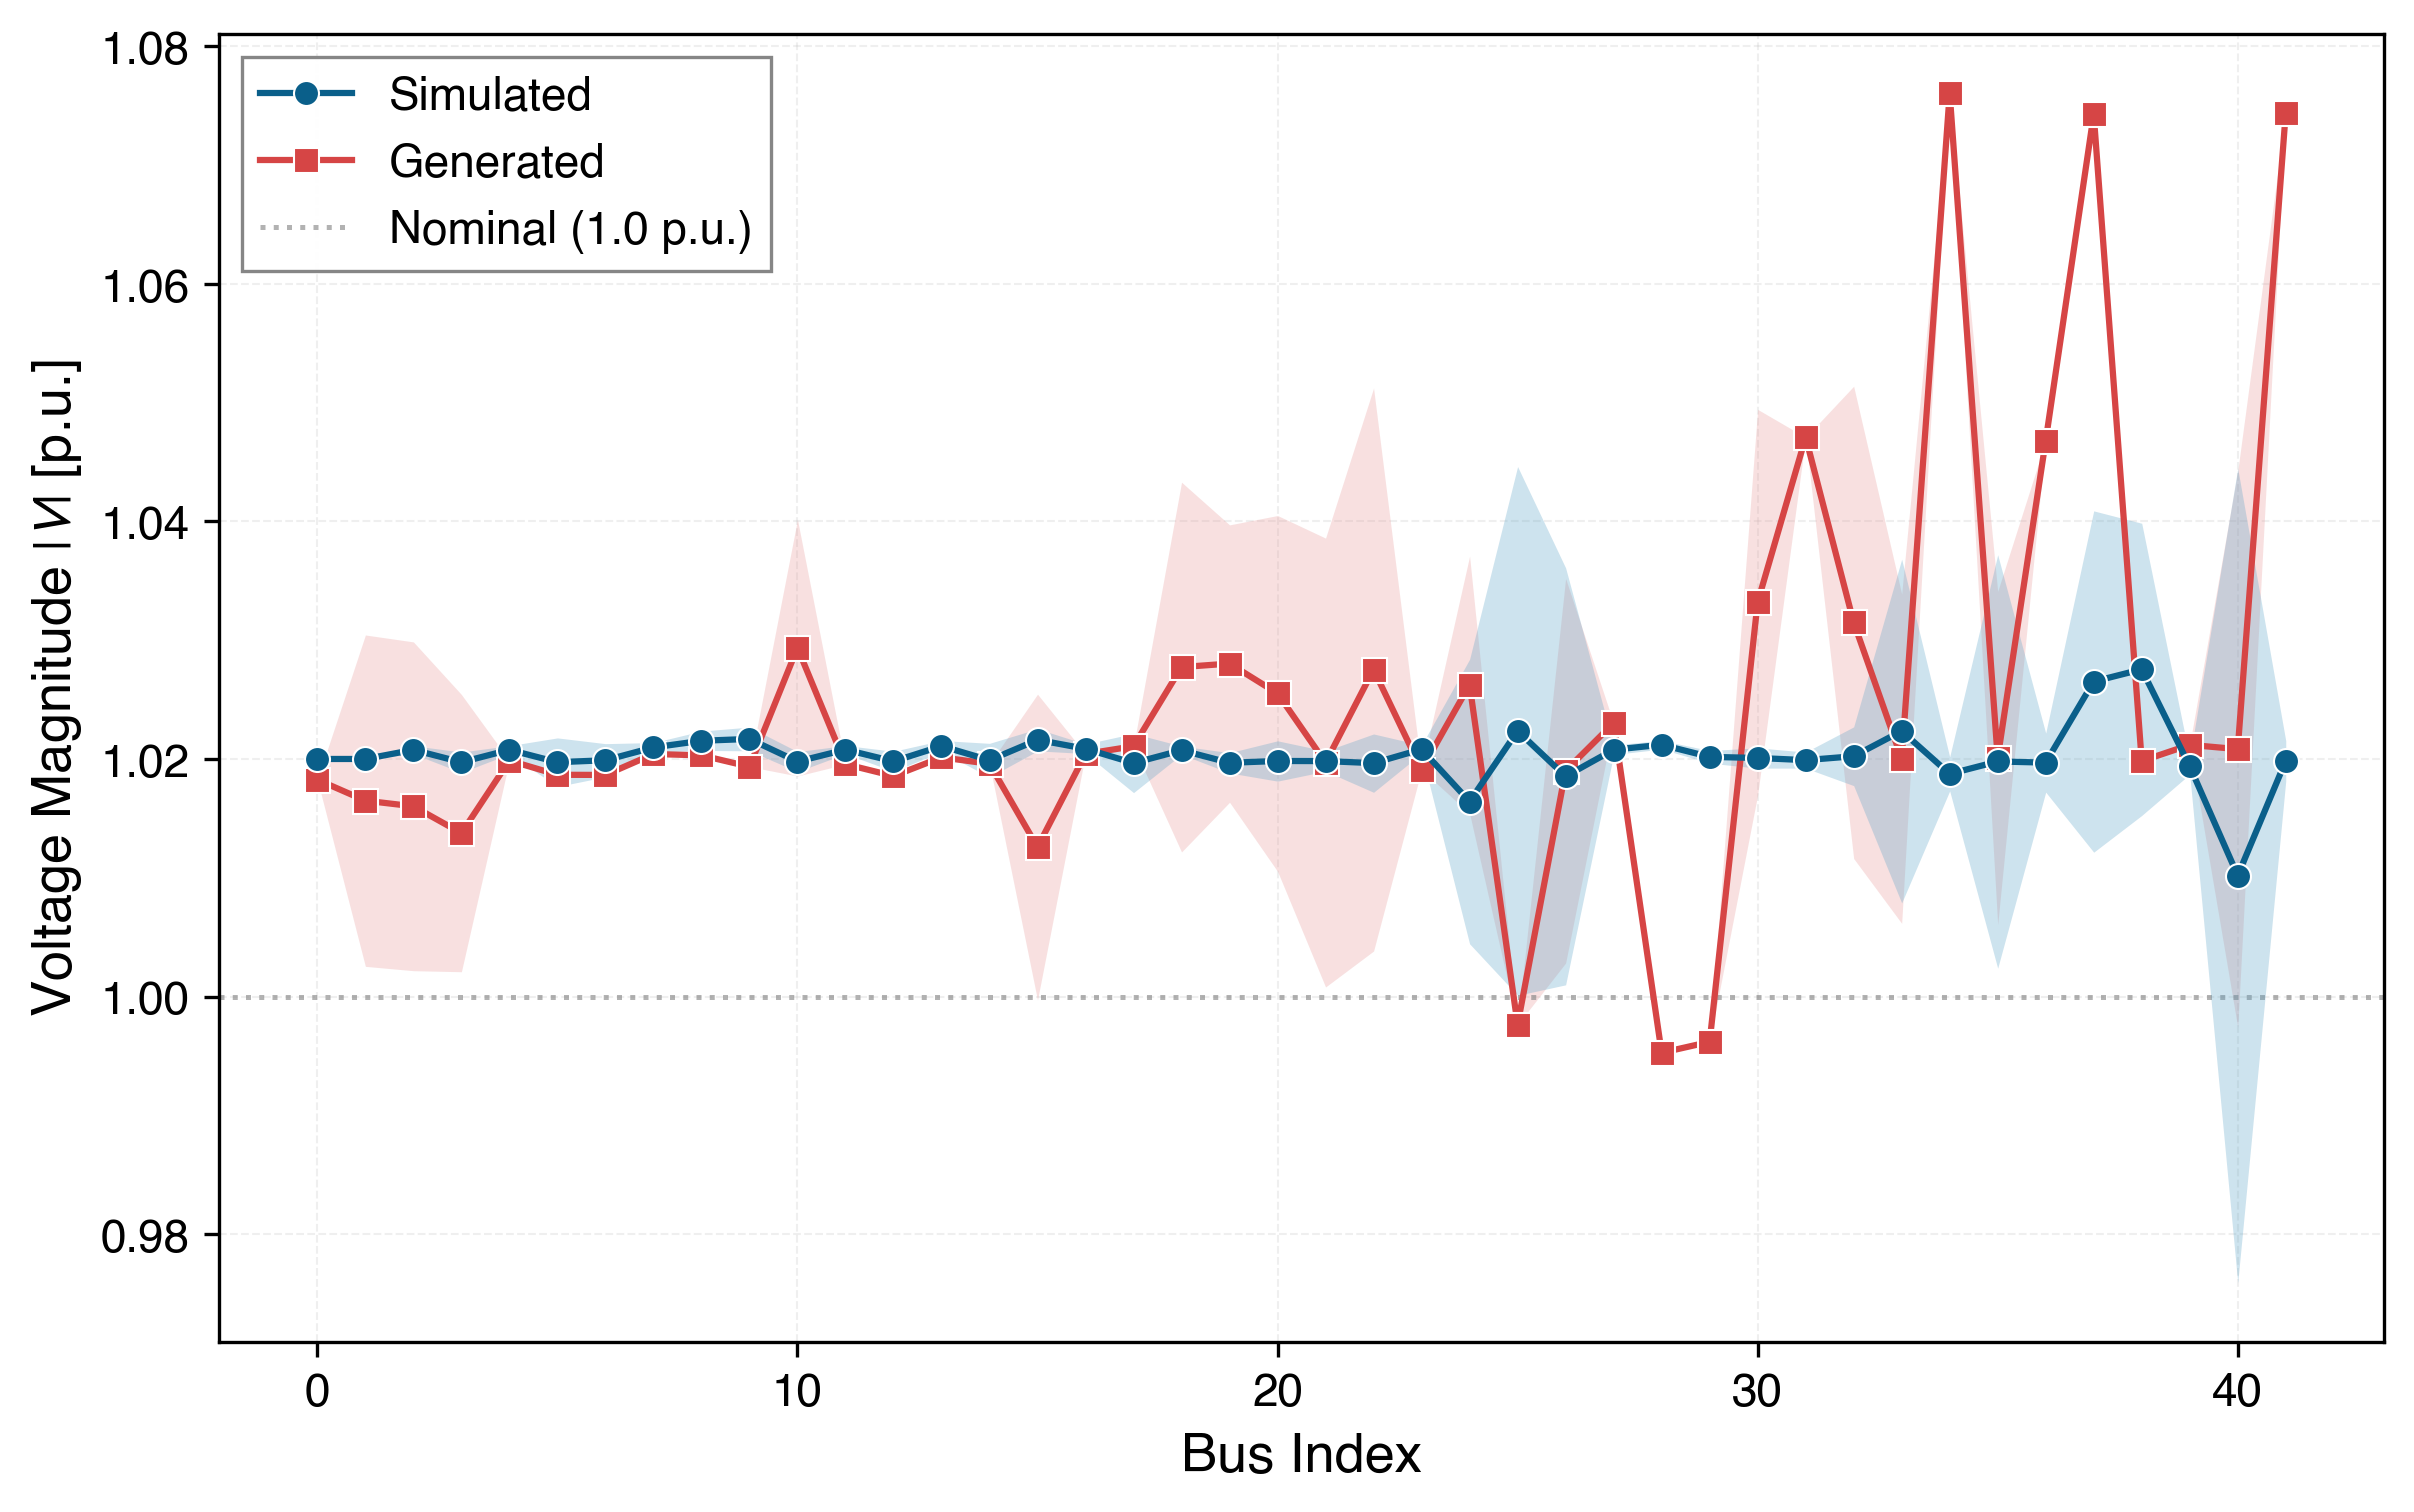

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set publication-quality style with modern fonts
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Proxima Nova', 'Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stixsans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'semibold'

# Create figure with better proportions
fig, ax = plt.subplots(figsize=(8, 5))

# Professional color palette
color_simulated = '#0A5F8A'  # Deep blue
color_generated = '#D64545'  # Warm red
fill_sim = '#5BA3C7'  # Light blue
fill_gen = '#E89B9B'  # Light red

x = range(len(simulated_mean))

# Plot simulated data (markers only)
ax.plot(x, simulated_mean, 
        color=color_simulated, 
        marker='o',
        markersize=6,
        linestyle='-',
        markeredgewidth=0.5,
        markeredgecolor='white',
        label='Simulated',
        zorder=4)
ax.fill_between(x, 
                simulated_mean - simulated_std, 
                simulated_mean + simulated_std, 
                color=fill_sim,
                alpha=0.3,
                linewidth=0,
                zorder=2)

# Plot generated data (markers only)
ax.plot(x, generated_mean, 
        color=color_generated, 
        marker='s',
        markersize=6,
        linestyle='-',
        markeredgewidth=0.5,
        markeredgecolor='white',
        label='Generated',
        zorder=3)
ax.fill_between(x, 
                generated_mean - generated_std, 
                generated_mean + generated_std, 
                color=fill_gen,
                alpha=0.3,
                linewidth=0,
                zorder=1)

# Labels with proper formatting
ax.set_xlabel('Bus Index', fontweight='normal')
ax.set_ylabel('Voltage Magnitude $|V|$ [p.u.]', fontweight='normal')
# ax.set_title('Comparison of Simulated and Generated Voltage Profiles', 
#              fontweight='semibold', pad=15)

# Add subtle grid
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

# Clean up spines
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_linewidth(0.8)
# ax.spines['bottom'].set_linewidth(0.8)

# Optional: Add reference line at 1.0 p.u. (nominal voltage)
ax.axhline(y=1.0, color='gray', linestyle=':', linewidth=1.2, 
           alpha=0.6, zorder=1, label='Nominal (1.0 p.u.)')

# Legend with refined styling
legend = ax.legend(frameon=True, 
                   loc='best',
                   framealpha=0.95,
                   edgecolor='gray',
                   fancybox=False,
                   shadow=False)
legend.get_frame().set_linewidth(0.8)

# Tight layout
plt.tight_layout(pad=0.5)

# Save options
plt.savefig('FIG_voltage_comparison.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('voltage_comparison.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('voltage_comparison.png', dpi=300, bbox_inches='tight')

plt.show()

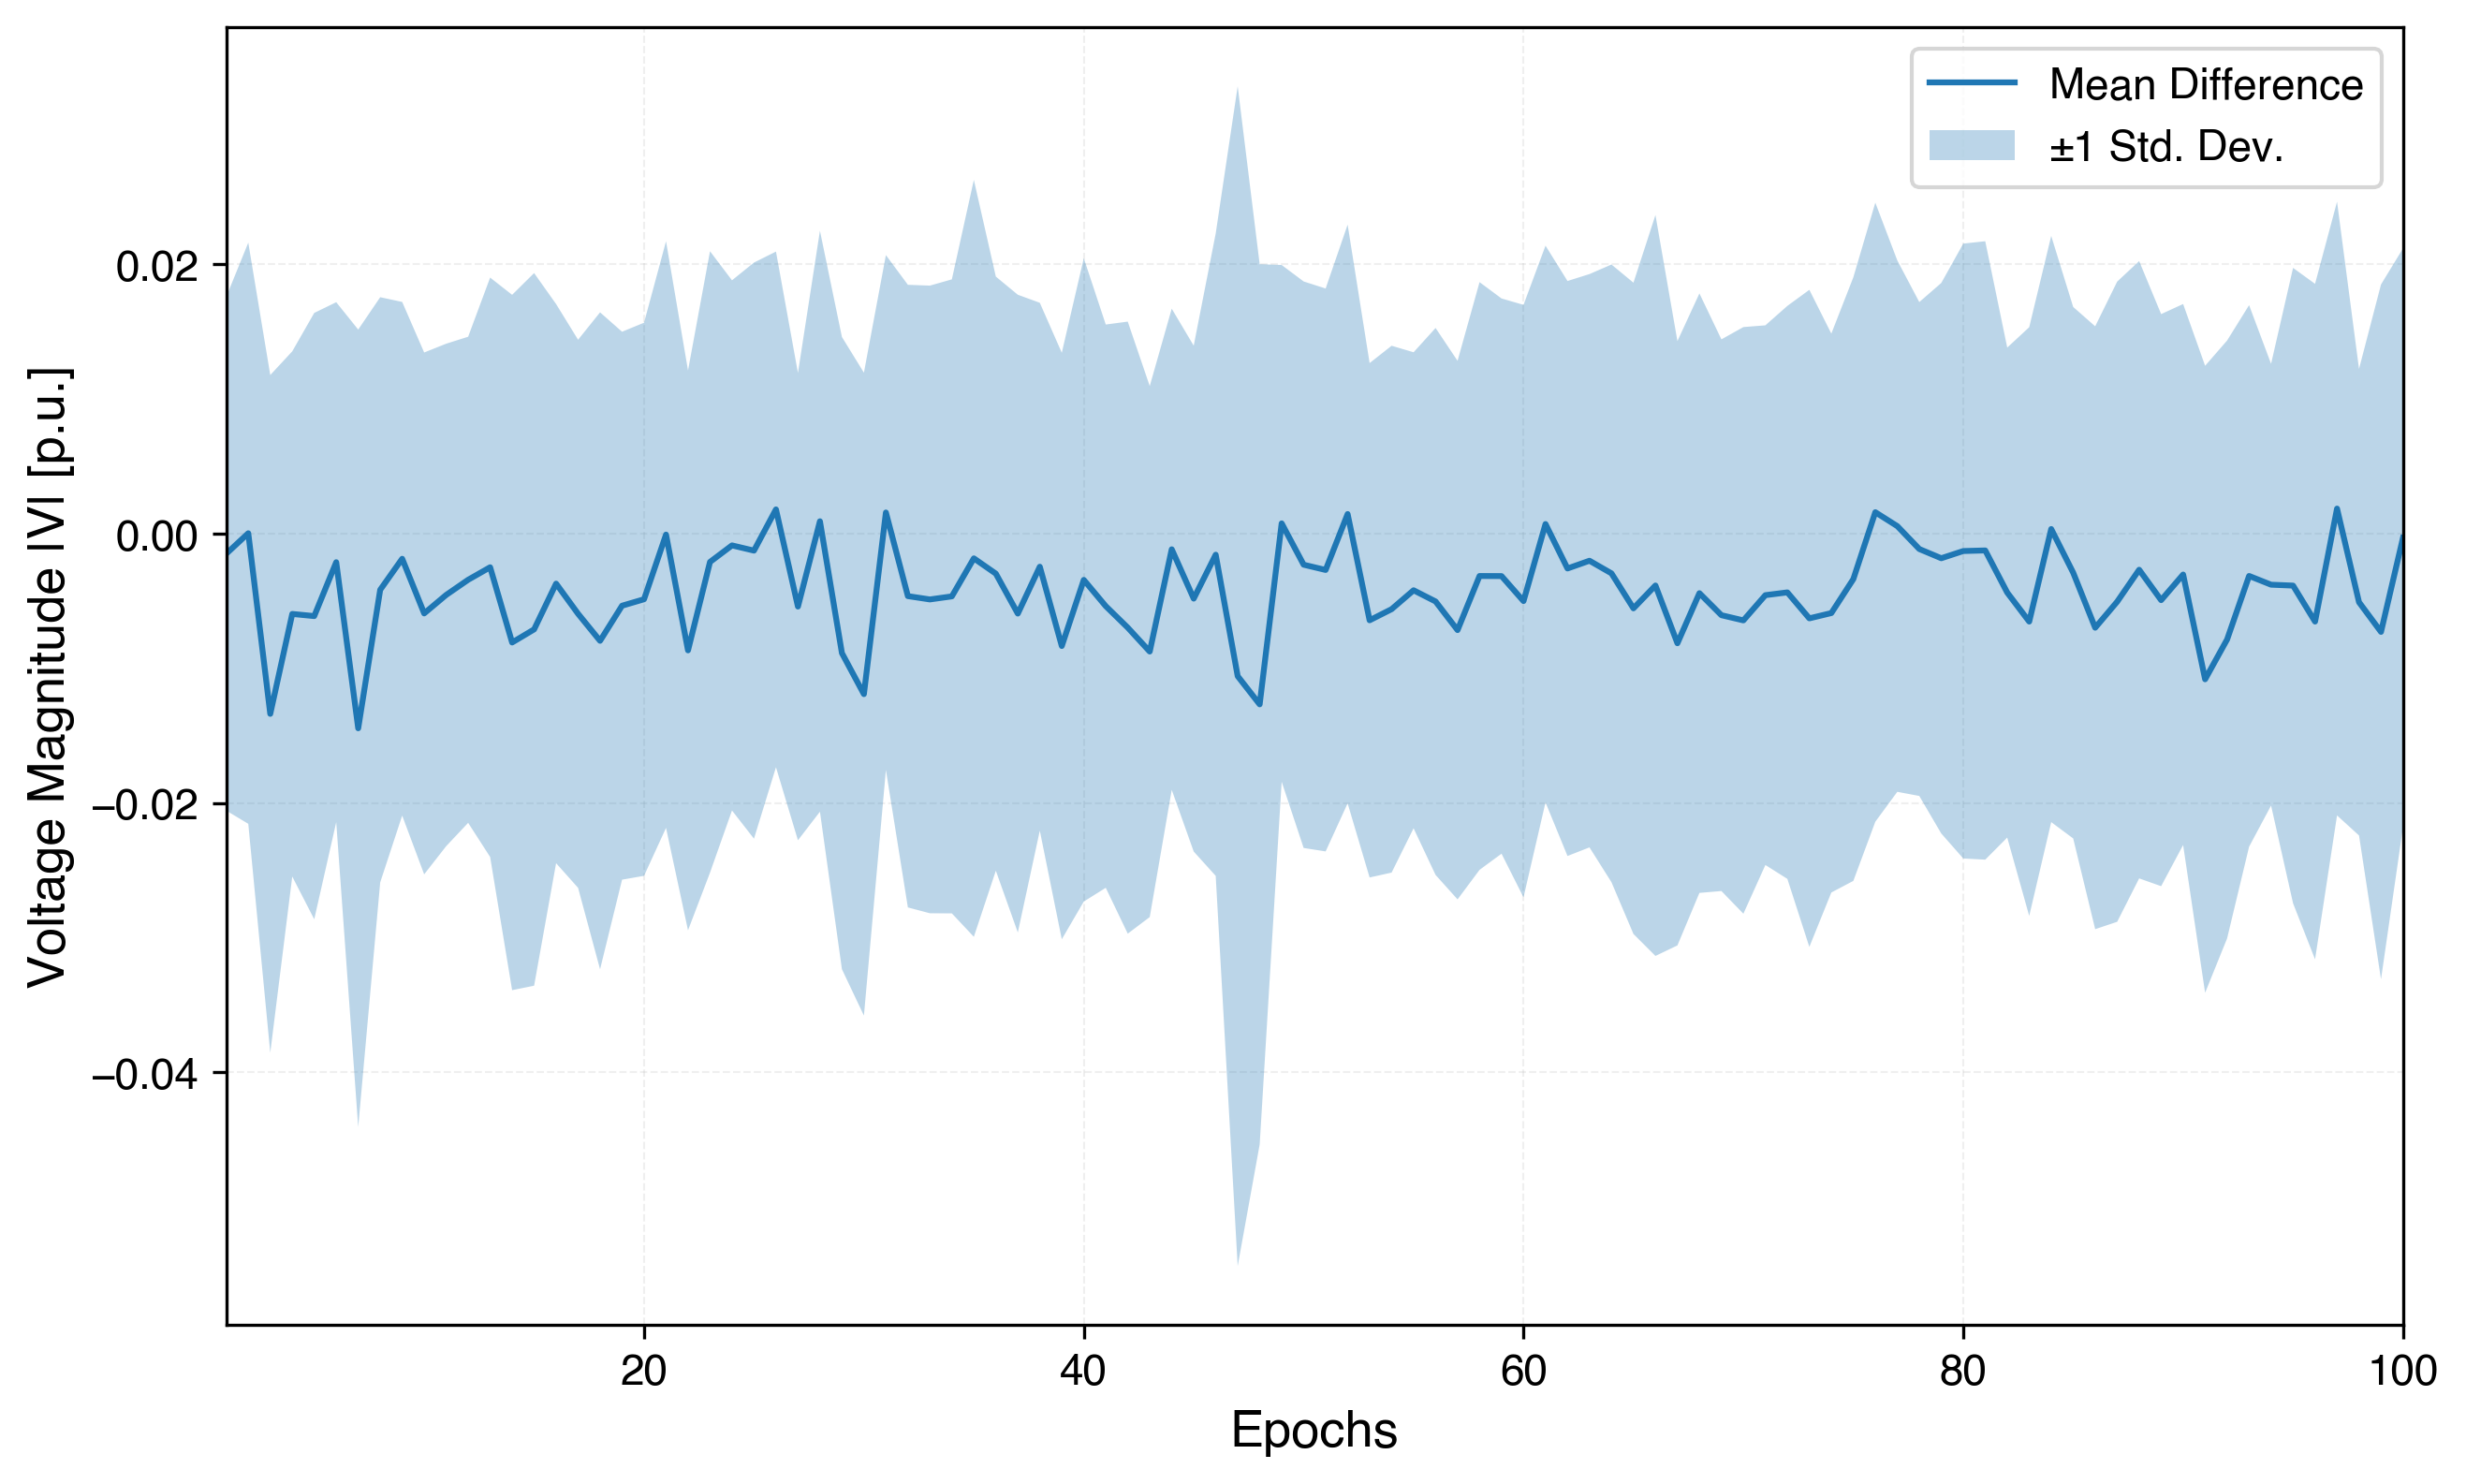

In [56]:
diff_sim_gen_df = simulated_v_pf_data_df - generated_v_df
diff_sim_gen_mean = diff_sim_gen_df.mean(axis=0)
diff_sim_gen_std = diff_sim_gen_df.std(axis=0)

# Create the plot 
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(diff_sim_gen_mean)) + 1
sns.lineplot(x=x, y=diff_sim_gen_mean, label='Mean Difference')
plt.fill_between(x, diff_sim_gen_mean - diff_sim_gen_std, diff_sim_gen_mean + diff_sim_gen_std, alpha=0.3, label='±1 Std. Dev.')
plt.xlabel('Epochs')
plt.ylabel('Voltage Magnitude |V| [p.u.]')
plt.legend()

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stixsans'  # Modern math font
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'semibold'


# Add grid for readability (subtle)
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=1)
ax.set_axisbelow(True)
ax.set_xlim(1,100)

plt.savefig('FIG_simulated_v_generated_mean.pdf', dpi=300, bbox_inches='tight')

plt.show()

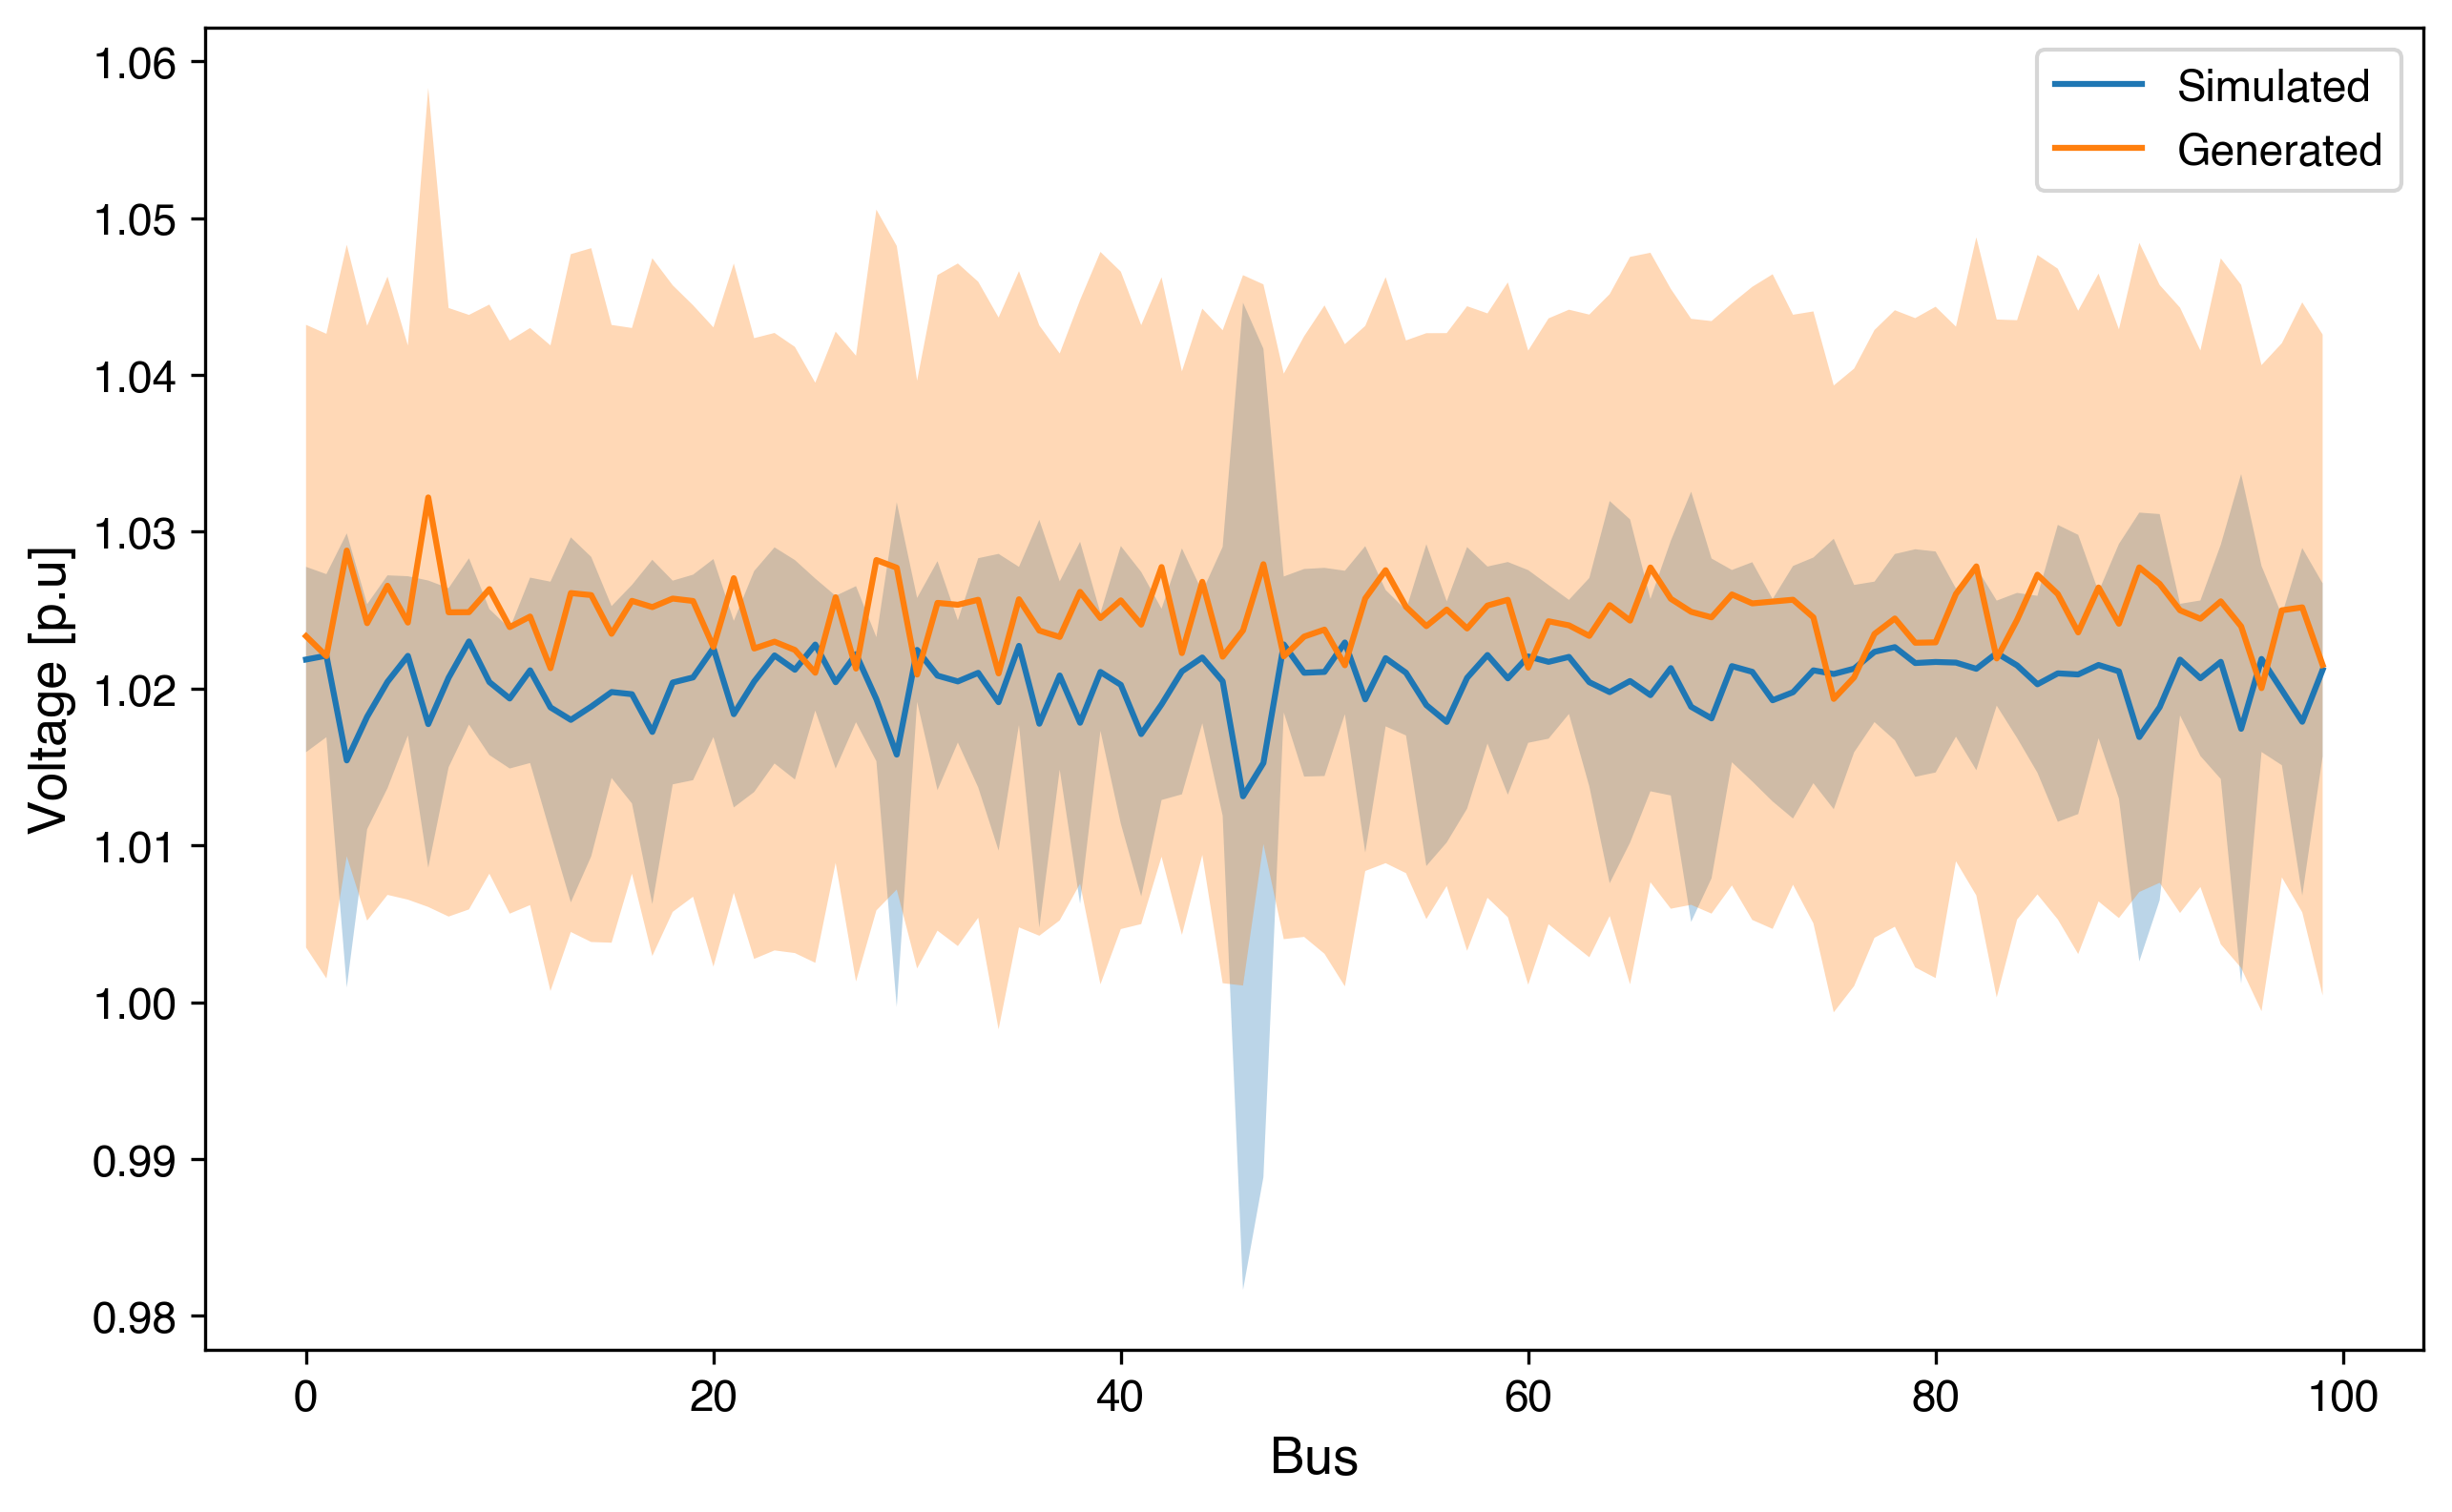

In [ ]:
# Calculate mean and standard deviation for both dataframes across epochs
simulated_mean = simulated_v_pf_data_df.mean(axis=0)
simulated_std = simulated_v_pf_data_df.std(axis=0)
generated_mean = generated_v_df.mean(axis=0)
generated_std = generated_v_df.std(axis=0)

adiff_sim_gen = simulated_v_pf_data - generated_v_df


# Create the plot
plt.figure(figsize=(10, 6))
x = range(len(simulated_mean))
sns.lineplot(x=x, y=simulated_mean, label='Simulated')
plt.fill_between(x, simulated_mean - simulated_std, simulated_mean + simulated_std, alpha=0.3)
sns.lineplot(x=x, y=generated_mean, label='Generated')
plt.fill_between(x, generated_mean - generated_std, generated_mean + generated_std, alpha=0.3)
plt.xlabel('Bus')
plt.ylabel('Voltage [p.u]')
plt.legend()
plt.show()